# Weekly Sync — 2026-W08 — Soslan Kabisov

> **Team:** Stepwise  
> **Week:** 2026-W08  
> **Owner:** Soslan Kabisov  
> **Date:** 2026-03-12

## ✅ Done 

#### 1. Обучена модель на датасете из 24-30 боксов. Увеличено число step_idx-примеров для каждого из 500_000 сэмплов датасета с 2 до 3, число эпох обучения – с 2 до 3. Добавлено логирование в tensorboard и валидационные метрики (вместо лосса по логитам, инференс модели несколько шагов с рендерингом и подсчетом метрик на stl (инференс на валидации происходит для последих 5 шагов от graund truth последовательности)). 

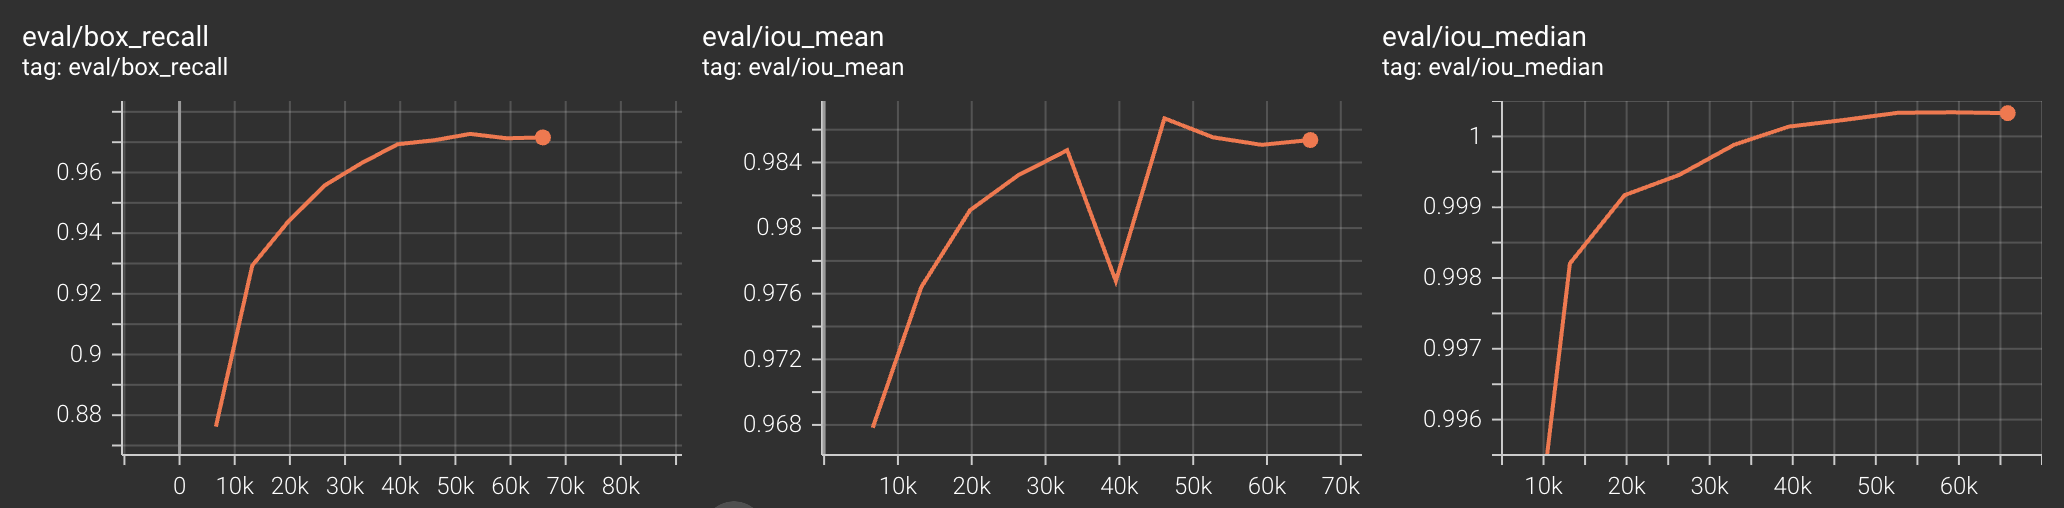
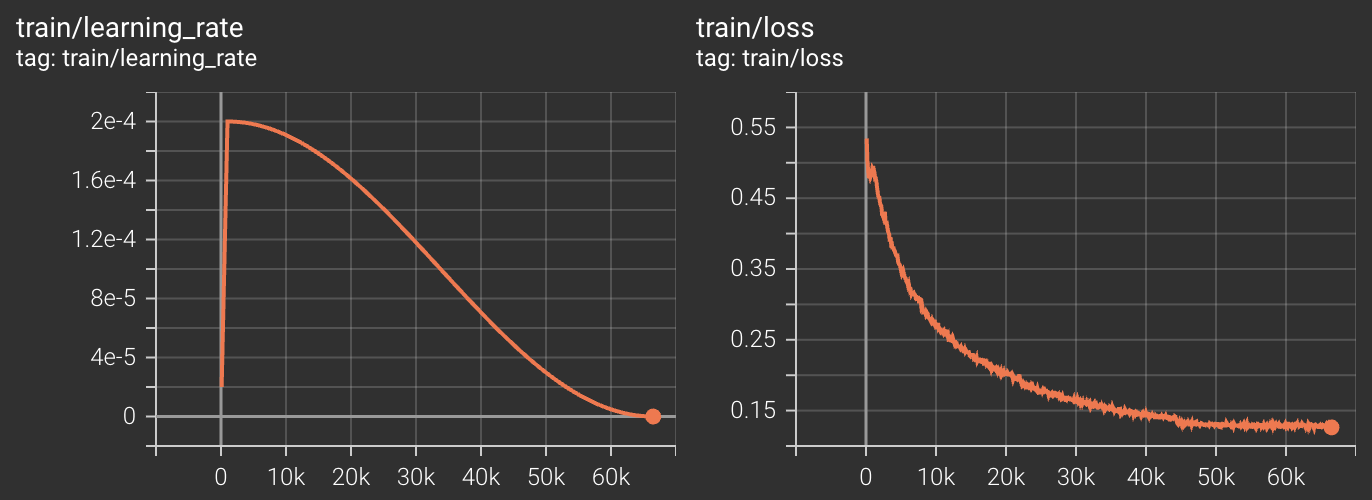

#### 2. Посчитаны метрики в сравнении с первой моделью, обученной на 8-12 боксах. 
#### Все датасеты содержат по 100 примеров с одим числом боксов. box_recall - доля боксов таргета предсказанных верно (если iou > 0.7). cd считается как cd(pred_mesh, target_mesh) / cd(target_mesh, target_mesh), чтобы не зависеть от площади поверхности меша

#### Модель, обученная на датасете из 24-30 боксов:

| dataset  | step_num | cd_mean | cd_median | iou_mean | iou_median | box_recall | ir (%) |
|----------|----------|---------|-----------|----------|------------|------------|--------|
| 8_boxes  | 8        | 71.06   | 6.28      | 0.91     | 0.96       | 0.93       | 2      |
| 10_boxes | 10       | 69.15   | 13.68     | 0.89     | 0.93       | 0.92       | 3      |
| 12_boxes | 12       | 110.57  | 21.65     | 0.86     | 0.92       | 0.86       | 2      |
| 16_boxes | 16       | 139.28  | 20.98     | 0.82     | 0.87       | 0.81       | 2      |
| 20_boxes | 16       | 180.03  | 50.82     | 0.80     | 0.83       | 0.77       | 5      |
| 24_boxes | 16       | 414.98  | 31.22     | 0.82     | 0.87       | 0.75       | 4      |
| 30_boxes | 16       | 95.57   | 34.32     | 0.75     | 0.80       | 0.67       | 9      |

#### Модель, обученная на датасете из 8-12 боксов:

| dataset  | step_num | cd_mean | cd_median | iou_mean | iou_median | box_recall | ir (%) |
|----------|----------|---------|-----------|----------|------------|------------|--------|
| 8_boxes  | 8        | 237.01  | 19.09     | 0.86     | 0.92       | 0.82       | 3      |
| 10_boxes | 10       | 205.27  | 27.65     | 0.83     | 0.89       | 0.78       | 5      |
| 12_boxes | 12       | 662.42  | 107.55    | 0.71     | 0.78       | 0.66       | 3      |
| 16_boxes | 16       | 585.34  | 100.61    | 0.65     | 0.71       | 0.49       | 7      |
| 20_boxes | 16       | 604.48  | 233.68    | 0.60     | 0.61       | 0.39       | 6      |
| 24_boxes | 16       | 1039    | 146.62    | 0.63     | 0.73       | 0.37       | 1      |
| 30_boxes | 16       | 694.44  | 227.79    | 0.49     | 0.52       | 0.25       | 2      |

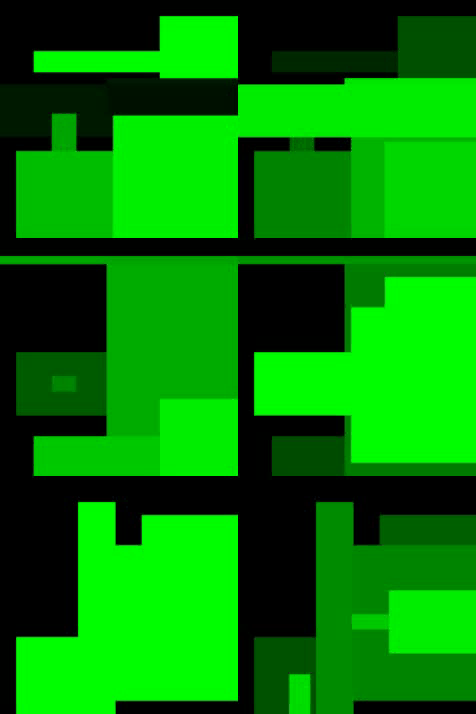

#### 3. Ошибки модели, обученной на 8-12 боксах

In [41]:
import cv2
from PIL import Image

def extract_pil_images_from_mp4(video_path):
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        raise ValueError("Error opening video file")
    
    pil_images = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convert BGR (OpenCV) to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Convert numpy array to PIL Image
        pil_image = Image.fromarray(frame_rgb)
        pil_images.append(pil_image)
    
    cap.release()
    return pil_images


# Example usage
images = extract_pil_images_from_mp4("/Users/soslankabisov/PycharmProjects/data_for_stepwise_results/first_model_trained_on_8-12boxes/test_8boxes/bad/8_8boxes_10_steps.mp4")
print(f"Extracted {len(images)} frames.")

Extracted 11 frames.


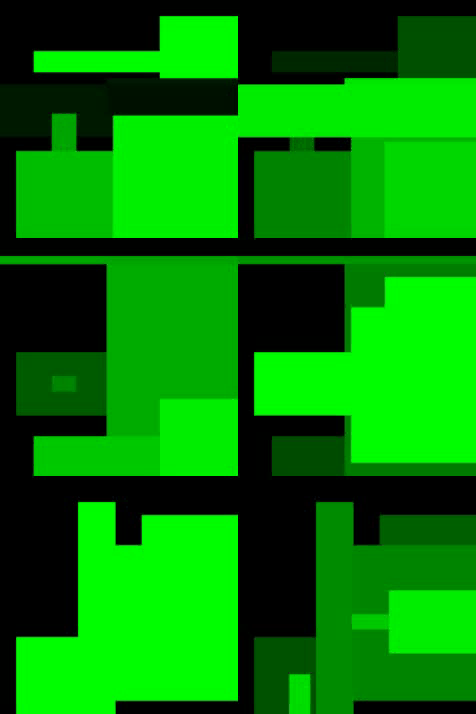

In [44]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np
from PIL import Image

def animate(images):
  # Assuming you have a list of images (as numpy arrays or PIL Images)
  # Example: creating a list of random images

  # Create figure
  fig, ax = plt.subplots()
  ax.axis('off')  # Hide axes
  im = ax.imshow(images[0])

  def update(frame):
      im.set_array(images[frame])
      return [im]

  # Create animation
  ani = animation.FuncAnimation(fig, update, frames=len(images),
                              interval=800, blit=True)

  # Display in Colab
  plt.close()  # Prevent duplicate display
  return HTML(ani.to_jshtml())


animate(images)

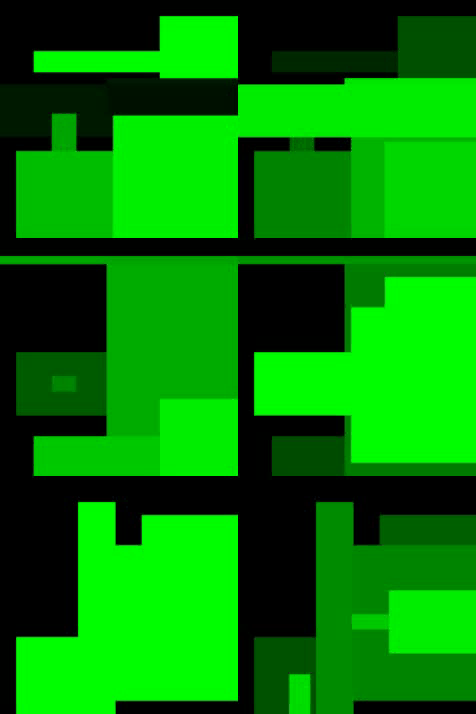


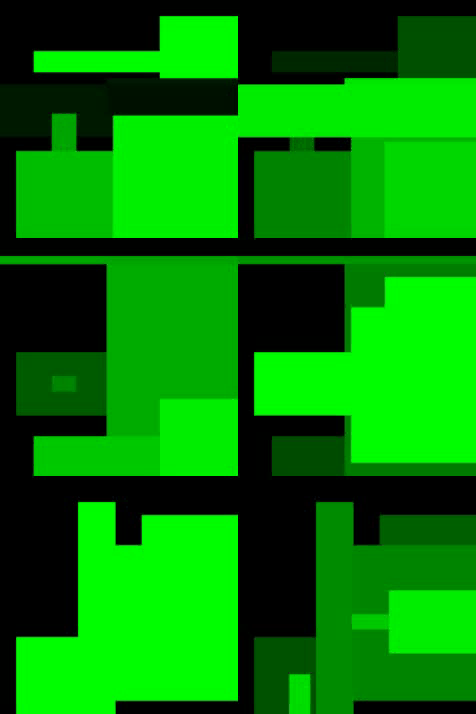

In [37]:
from IPython.display import HTML, display
import base64

# gif_path = "your_animation.gif"

with open(gif_path, "rb") as f:
    b64 = base64.b64encode(f.read()).decode("ascii")

display(HTML(f'''
<img src="data:image/gif;base64,{b64}" />
'''))

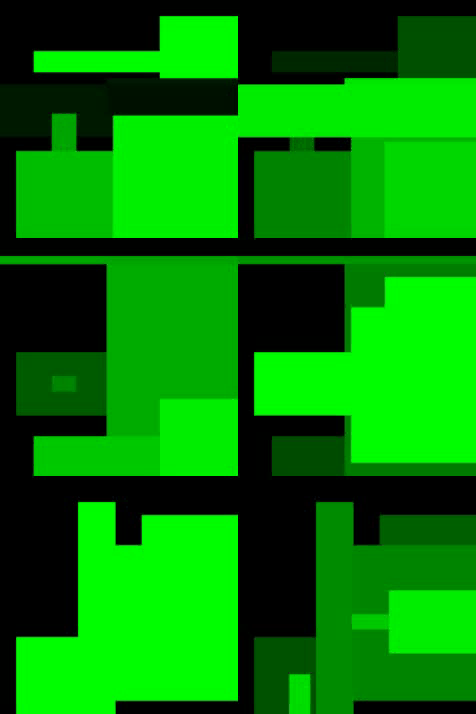

In [36]:
from IPython.display import Image

Image(gif_path)


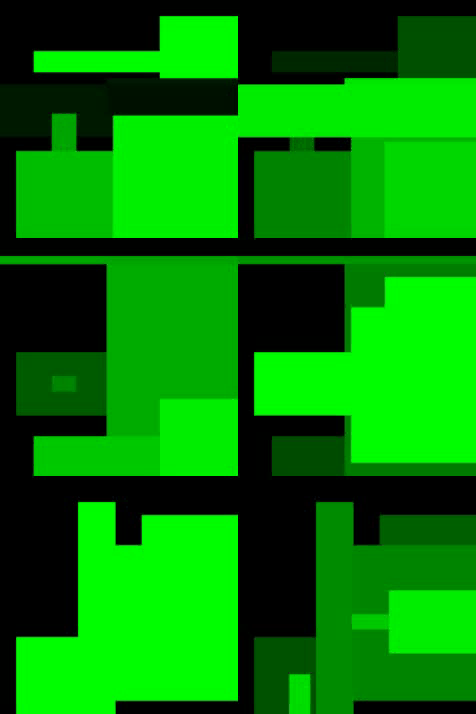

In [35]:
from IPython.display import HTML
import base64

# Path to your gif
gif_path = "/Users/soslankabisov/Documents/SYNC/8_8boxes_10_steps.gif"

with open(gif_path, "rb") as f:
    gif_data = f.read()

data_url = base64.b64encode(gif_data).decode("utf-8")

HTML(f'<img src="data:image/gif;base64,{data_url}" loop="infinite">')

In [24]:
import cv2
import imageio
import numpy as np
from pathlib import Path

def mp4_to_gif_opencv(input_path, output_path, fps=10, scale=1.0):
    """
    Convert MP4 video to GIF using OpenCV and imageio
    
    Args:
        input_path (str): Path to input MP4 file
        output_path (str): Path to output GIF file
        fps (int): Frames per second for output GIF
        scale (float): Scale factor for resizing (1.0 = original size)
    """
    # Open the video file
    cap = cv2.VideoCapture(input_path)
    
    if not cap.isOpened():
        print("Error: Could not open video file")
        return
    
    # Get video properties
    original_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Video info: {total_frames} frames at {original_fps:.2f} fps")
    
    # Calculate frame sampling rate
    frame_interval = max(1, int(original_fps / fps))
    
    frames = []
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Sample frames based on desired fps
        if frame_count % frame_interval == 0:
            # Convert BGR to RGB (OpenCV uses BGR, GIF uses RGB)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Resize if needed
            if scale != 1.0:
                height, width = frame_rgb.shape[:2]
                new_width = int(width * scale)
                new_height = int(height * scale)
                frame_rgb = cv2.resize(frame_rgb, (new_width, new_height))
            
            frames.append(frame_rgb)
        
        frame_count += 1
        
        # Progress indicator
        if frame_count % 100 == 0:
            print(f"Processed {frame_count}/{total_frames} frames")
    
    cap.release()
    
    # Save as GIF
    print(f"Saving GIF with {len(frames)} frames at {fps} fps...")
    imageio.mimsave(output_path, frames, fps=fps)
    print(f"GIF saved to: {output_path}")

# Example usage
input_file = "/Users/soslankabisov/Documents/SYNC/8_8boxes_10_steps.mp4"
output_file = "/Users/soslankabisov/Documents/SYNC/8_8boxes_10_steps.gif"

# Convert with custom settings
mp4_to_gif_opencv(
    input_path=input_file,
    output_path=output_file,
    fps=0.8,        # Output GIF framerate
    scale=1      # Reduce size by 50%
)

# Usag

Video info: 11 frames at 1.00 fps
Saving GIF with 11 frames at 0.8 fps...
GIF saved to: /Users/soslankabisov/Documents/SYNC/8_8boxes_10_steps.gif


## 🎯 Plan for next week 
- Эксперименты с пошаговым предсказаниям на картинках на датасете с боксами

## ❗Risks / Decisions (optional)
- 

Идеи: 
1) 



## 🔗 References (optional)
- 
